# Data Context

This analysis covers two datasets. The first is LUND-PROBE (Rogowski et al., 2025), which will be the public benchmark containing 432 prostate MRgRT patients from Skåne University Hospital, 
Lund, Sweden. Each patient folder contains a synthetic CT (sCT) image, an MRI (T2-Weighted), interpolated and original dose distributions, and segmentation masks for nine structures: CTV, PTV, Bladder, Rectum, FemoralHead_L, FemoralHead_R, PenileBulb, Genitalia, and BODY. The sCT serves as the primary model input because dose calculation depends on tissue density, which MR alone does not encode. Files are sorted in NIfTI format (.nii.gz) and organised per patient under a basePart directory with 432 patients and an extendedPart with an additional 35 annotated cases. LUND-PROBE is used as a reproducible public benchmark for controlled model comparision.

The second dataset is a private pancreatic MRgRT cohort from Amsterdam UMC, comprimising approximately *****

In [18]:
# Summary table comparing key dataset properties side by side.
# Pancreatic cohort values marked as TBC (to be confirmed) where the
# data format has not yet been verified with the clinical supervisor.

summary_table = pd.DataFrame({
    "Property": [
        "Disease site",
        "Treatment modality",
        "Total patients",
        "Training / evaluation split",
        "Image format",
        "Primary input modality",
        "Dose format",
        "Structure masks",
        "Fractions per patient",
        "Image dimensions (approx.)",
        "In-plane voxel spacing",
        "Slice thickness",
        "Data availability",
    ],
    "LUND-PROBE": [
        "Prostate",
        "MR-guided radiotherapy (SBRT)",
        "432 (basePart)",
        "Not pre-split (patient-level split applied)",
        "NIfTI (.nii.gz)",
        "Synthetic CT (sCT)",
        "Interpolated onto sCT grid",
        "9 structures per patient",
        "Single fraction per folder",
        "~756 × 1024 × 88 (variable)",
        "0.4375–0.4688 mm",
        "2.5 mm",
        "Public",
    ],
    "AUMC Pancreatic": [
        "Pancreas",
        "MR-guided radiotherapy (SBRT)",
        "~101 (74 train + 27 eval)",
        "Pre-split into Training-nifti / Evaluation-nifti",
        "NIfTI (.nii.gz) + raw DICOM",
        "MR image (TBC)",
        "TBC — DICOM dose files present in source",
        "TBC — DICOM RTSS present in source",
        "Multiple fractions per patient (0–5+)",
        "266 × 266 × 144",
        "1.50 mm",
        "3.0 mm",
        "Private (Amsterdam UMC)",
    ]
}).set_index("Property")

summary_table

,LUND-PROBE,AUMC Pancreatic
Property,,
Disease site,Prostate,Pancreas
Treatment modality,MR-guided radiotherapy (SBRT),MR-guided radiotherapy (SBRT)
Total patients,432 (basePart),~101 (74 train + 27 eval)
Training / evaluation split,Not pre-split (patient-level split applied),Pre-split into Training-nifti / Evaluation-nifti
Image format,NIfTI (.nii.gz),NIfTI (.nii.gz) + raw DICOM
Primary input modality,Synthetic CT (sCT),MR image (TBC)
Dose format,Interpolated onto sCT grid,TBC — DICOM dose files present in source
Structure masks,9 structures per patient,TBC — DICOM RTSS present in source
Fractions per patient,Single fraction per folder,Multiple fractions per patient (0–5+)


## LUND-PROBE Analysis

The following analysis wil show the lUND-PROBE dataset across five levels: dataset inventory, image geometry, intensity and acquisition properties, dose distribution, and structure volumes. Together these observations inform the preprocessing decisions made in the following pipeline.

### 3.1 Dataset Inventory

First we confirm whether all expected patients are present and that the dataset's complete metadata, the geometry CSV and the missing structures JSON, are accessible and interpretable. Here the corpus-level picture is established before any image-level is loaded.

In [2]:
# Standard library
import os
import json

# Third-party: data and visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Medical imaging
import nibabel as nib
from pathlib import Path

# ----------------------------------------------------------------------
# Dataset paths 
# BASE_PATH points to the 432-patient basePart on the network drive.
# The metadata CSV and missing structures JSON sit one level up.
# ----------------------------------------------------------------------
BASE_PATH = Path(r"\\vumc.nl\Onderzoek\s4e-gpfs2\rath-research-01\Research\Research_Kidney_AI_OB_ABR_MP_NGA_Joris\NIKA\LUnd_dataset\lund-probe\lund-probe\basePart")

METADATA_CSV = BASE_PATH.parent / "patGeometryInformation_basePart.csv"
MISSING_JSON = BASE_PATH.parent / "missingStructures_basePart.json"

# Collect patient directories in sorted order for reproducibility
patient_dirs = sorted([d for d in BASE_PATH.iterdir() if d.is_dir()])

print(f"Patients found: {len(patient_dirs)}")
print(f"First patient: {patient_dirs[0].name if patient_dirs else 'None'}")
print(f"Last: {patient_dirs[-1].name if patient_dirs else 'None'}")

Patients found: 432
First patient: newAcq_01d2150e9b50efa1
Last: oldAcq_fffac611ac446b6f


## 1. Corpus-Level Overview

With 432 patients confirmed, the next step is to inspect the metadata files provided with LUND-PROBE. The geometry CSV contains per-patient image dimensions, voxel spacing, and structure volumes. The missing structures JSON flags any patients where segmentations are absent. Together these give a dataset-wide picture before any image-level loading.

In [3]:
# Load the per-patient geometry metadata provided with LUND-PROBE.
# This tells is image dimensions, voxelspacing, intesnity statistics,
# and structure volumes for every patient, without loading a single image.

df = pd.read_csv(METADATA_CSV, sep=";")

print(f"Metadata shape: {df.shape}")  # (rows, columns) — expect ~432 rows
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst two rows:")
df.head(2)

Metadata shape: (432, 9)

Column names:
['patient', 'sCTMatrixSizeOrig', 'sCTVoxelSizeOrig (mm)', 'mriMatrixSize', 'mriVoxelSize (mm)', 'doseMatrixSizeOrig', 'doseVoxelSizeOrig', 'doseMin (Gy)', 'doseMax (Gy) ']

First two rows:


,patient,sCTMatrixSizeOrig,sCTVoxelSizeOrig (mm),mriMatrixSize,mriVoxelSize (mm),doseMatrixSizeOrig,doseVoxelSizeOrig,doseMin (Gy),doseMax (Gy)
0,oldAcq_ca05ccf044225231,"(756, 1024, 88)","(0.4375, 0.4375, 2.5)","(1024, 1024, 88)","(0.4375, 0.4375, 2.5)","(108, 162, 88)","(2.5, 2.5, 2.5)",0.0,44.30
1,oldAcq_0cbde6c35fb03c23,"(756, 1024, 88)","(0.4375, 0.4375, 2.5)","(1024, 1024, 88)","(0.4375, 0.4375, 2.5)","(116, 174, 88)","(2.5, 2.5, 2.5)",0.0,44.19


to be checked in the preprocessing stage:
- dimensions sct and mri should be the same
    -> now: sct and mri have different in-plane sizes (756 vs 1024). sCT doesn't cover the full field of view of the MR. sCT often crops body the body region. 
    -> input sizes need to be consistent

for training:
- use the dose_interpolated.mii.gz (resampled version)

### 3.2 Image Geometry

With 432 patients confirmed, next is whether image geometry is consistent across the cohort. Inconsistetn voxel spacing or matrix size across patients would require resampling during preprocessing bring all volumes onto a common spatial grid before moedl training.

In [4]:
# Consitensy check of image geometry across all 432 patients. 
# For a well-curated public dataset uniformity is expected, but important to verify. 
# Inconsitency in spacing or dimesnions would require per-patient resampling during preprocessing.

print("=== sCT Matrix Size (unique values) ===")
print(df["sCTMatrixSizeOrig"].value_counts())

print("\n=== sCT Voxel Size (unique values) ===")
print(df["sCTVoxelSizeOrig (mm)"].value_counts())

print("\n=== MRI Matrix Size (unique values) ===")
print(df["mriMatrixSize"].value_counts())

print("\n=== Dose Range across patients ===")
print(f"Min dose (Gy): {df['doseMin (Gy)'].describe()}")
print(f"\nMax dose (Gy):\n{df['doseMax (Gy) '].describe()}")

=== sCT Matrix Size (unique values) ===
sCTMatrixSizeOrig
(756, 1024, 88)     99
(756, 1021, 88)     47
(756, 1022, 88)     45
(682, 1024, 88)     43
(756, 1020, 88)     37
(756, 1023, 88)     33
(682, 1023, 88)     21
(716, 1024, 88)     15
(682, 1022, 88)     13
(756, 1019, 88)     10
(682, 1021, 88)      8
(716, 1023, 88)      6
(682, 1020, 88)      5
(682, 1019, 88)      4
(716, 1021, 88)      4
(716, 1022, 88)      3
(716, 1020, 88)      3
(682, 1018, 88)      3
(682, 1016, 88)      2
(682, 1012, 88)      2
(682, 1017, 88)      2
(756, 1024, 79)      2
(756, 1022, 85)      2
(756, 1019, 85)      1
(756, 1011, 88)      1
(716, 1019, 88)      1
(682, 1009, 88)      1
(756, 1022, 78)      1
(682, 1015, 88)      1
(756, 1021, 85)      1
(756, 1021, 77)      1
(756, 1019, 79)      1
(682, 993, 88)       1
(858, 1009, 88)      1
(756, 1022, 87)      1
(682, 949, 88)       1
(682, 1004, 88)      1
(858, 1024, 88)      1
(756, 1007, 88)      1
(756, 1019, 80)      1
(756, 1020, 81)      1

### Observations: Image Geometry and Dose Range - Findings important for preprocessing:

- sCT matrix size: significant variation,  46 unique dimension combinations found.
    - Z dimension (no. of slices) is almost always 88. but some with 79, 85, 77, 85, 104 slices = outliers.
    - X dimension (field of view reflecting different body sizes) varies between 3 main values: 682, 716, and 756 (latter most common, approx. 60%).
    - Y dimension small fluctuations around 1024 due to minor differences in how the scan was reconstructed.
> Needs resampling and cropping/padding strategy.

- sCT voxel spacing: three main groups, majority (310/ 432 patients) have 0.4375mm in-plane spacing. others; 0.4688mm.
    -  Z spacing is consistently 2.5mm across everyone.
> Needs resampling to a common voxel spacing, most likely 0.4375mm in-plane since that's the most prevalent. 

- MRI matrix size: uniform, no need for preprocessing.
    -  1024×1024×88.
> Reference for sCT to match it?

- Dose range: 
    - min dose = 0.0 (expected), voxels outside treatment field receive no dose.
    - max dose = 44.25 Gy, STD = 0.43 Gy, dose scales consistent across patients.
    - outliers: 38.32 Gy and 45.89 Gy.

In [5]:
# Loading the missing structures JSON to understand which patient have missing segmentations.
# Patients with missing crittical structures (e.g. CTV, PTV) may need to be excluded from training,
# So we need to now how many there are and which structures are missing.

with open(MISSING_JSON, "r") as f:
    missing = json.load(f)

print(f"Patients with at least one missing structure: {len(missing)}")
print(f"\nFirst entry as example:")

# Show just the first entry so we understand the data format
first_key = list(missing.keys())[0]
print(f"  Patient: {first_key}")
print(f"  Missing: {missing[first_key]}")

Patients with at least one missing structure: 48

First entry as example:
  Patient: oldAcq_522d43d20ac30f75
  Missing: ['mask_PenileBulb.nii.gz']


In [6]:
# Summarise which structures are missing and how frequently.
# This tells us whether missing data affects critical structures (CTV, PTV)
# or only secondary organs at risk — which determines whether affected
# patients need to be excluded from training.
from collections import Counter

# Flatten all missing structure names across all affected patients
all_missing = []
for patient_id, structures in missing.items():
    all_missing.extend(structures)

missing_counts = Counter(all_missing)

print(f"Missing structure frequencies across {len(missing)} patients:\n")
for structure, count in missing_counts.most_common():
    print(f"  {structure:<35s} missing in {count} patient(s)")

Missing structure frequencies across 48 patients:

  mask_PenileBulb.nii.gz              missing in 29 patient(s)
  mask_Genitalia.nii.gz               missing in 24 patient(s)


### Missing structure findings.

- Only 2 secondary OARs are missing: PenileBulb and Genitalia.
- No PTV or CTV are missing.
> For model training to learn dose mapping it requires the PTV and CTV, and since they're not missing the data is of good quality for training.

Some patients mis both the penilebulb and genitalia, possibly because of the contouring protocol varied across the years the data was collected.

> All 432 patients will be included in training. for structure masks encoding penilebulb and genitalia will be optional of when those structures are missing value will be 0s for that channel (mention in methodology).

In [7]:
# Corpus-level summary.
# This consolidates the key dataset properties into one readable table,
# which can be referenced directly in the thesis methodology section.

summary = {
    "Total patients": len(patient_dirs),
    "Patients with missing structures": len(missing),
    "Critical structures missing (CTV/PTV)": 0,
    "Unique sCT in-plane spacings": df["sCTVoxelSizeOrig (mm)"].nunique(),
    "Dominant sCT spacing (most common)": df["sCTVoxelSizeOrig (mm)"].value_counts().index[0],
    "MRI matrix size (all patients)": df["mriMatrixSize"].unique()[0],
    "Mean max dose (Gy)": round(df["doseMax (Gy) "].mean(), 2),
    "Std max dose (Gy)": round(df["doseMax (Gy) "].std(), 2),
}

summary_df = pd.DataFrame.from_dict(summary, orient="index", columns=["Value"])
print(summary_df.to_string())

                                                       Value
Total patients                                           432
Patients with missing structures                          48
Critical structures missing (CTV/PTV)                      0
Unique sCT in-plane spacings                               5
Dominant sCT spacing (most common)     (0.4375, 0.4375, 2.5)
MRI matrix size (all patients)              (1024, 1024, 88)
Mean max dose (Gy)                                     44.25
Std max dose (Gy)                                       0.43


### 3.3 Intensity and Acquisition Analysis

Before inspecting dose and structures, we inspect the sCT intensity characteristics 
for a single patient and then across the full cohort. We also investigate whether 
the two acquisition groups visible in the patient ID prefixes, oldAcq and newAcq, 
differ systematically in geometry or intensity, since such a difference would affect 
how the dataset should be split.

## 2. Single Patient Inspection

Before analysing the full dataset, we load one patient to verify the file structure, inspect array shapes and intensity ranges, and visualise the three key volumes: the sCT input, the interpolated dose (prediction target), and an example structure mask. This grounds the corpus-level statistics in something concrete and confirms the loading pipeline works as expected.

In [8]:
# Load one patient for detailed inspection.
# We pick one patientin sorted order, not random, 
# to ensure this is reproducable and consistent across runs.
patient = patient_dirs[0]
sct_dir = patient / "sCT"

print(f"Inspecting patient: {patient.name}")

# --- Load sCT image ---
sct_img  = nib.load(sct_dir / "image.nii.gz")
sct_data = sct_img.get_fdata()

# --- Load interpolated dose (our prediction target) ---
dose_img  = nib.load(sct_dir / "dose_interpolated.nii.gz")
dose_data = dose_img.get_fdata()

# --- Load one structure mask: the CTV (treatment target) ---
ctv_img  = nib.load(sct_dir / "mask_CTVT_427.nii.gz")
ctv_data = ctv_img.get_fdata()

# Print shape and spacing for each volume
for name, img, data in [
    ("sCT",      sct_img,  sct_data),
    ("Dose",     dose_img, dose_data),
    ("CTV mask", ctv_img,  ctv_data),
]:
    zooms = img.header.get_zooms()
    print(f"\n{name}")
    print(f"  Shape:   {data.shape}")
    print(f"  Spacing: {zooms[0]:.4f} x {zooms[1]:.4f} x {zooms[2]:.4f} mm")
    print(f"  Range:   [{data.min():.2f}, {data.max():.2f}]")

Inspecting patient: newAcq_01d2150e9b50efa1

sCT
  Shape:   (993, 682, 88)
  Spacing: 0.4688 x 0.4688 x 2.5000 mm
  Range:   [-1000.00, 4143.00]

Dose
  Shape:   (993, 682, 88)
  Spacing: 0.4688 x 0.4688 x 2.5000 mm
  Range:   [0.00, 43.79]

CTV mask
  Shape:   (993, 682, 88)
  Spacing: 0.4688 x 0.4688 x 2.5000 mm
  Range:   [0.00, 1.00]


### Notes and observations:

The sCT range of -1000 to 4143 is in Hounsfield Units (HU), the standard scale for CT density. In this scale, -1000 HU is air, 0 HU is water, and bone is typically above 400 HU. The value 4143 is unusually high,  normal bone tops out around 1000-1500 HU, so this patient likely has a hip prosthesis or some dense implant. Worth keeping in mind as a potential outlier case.



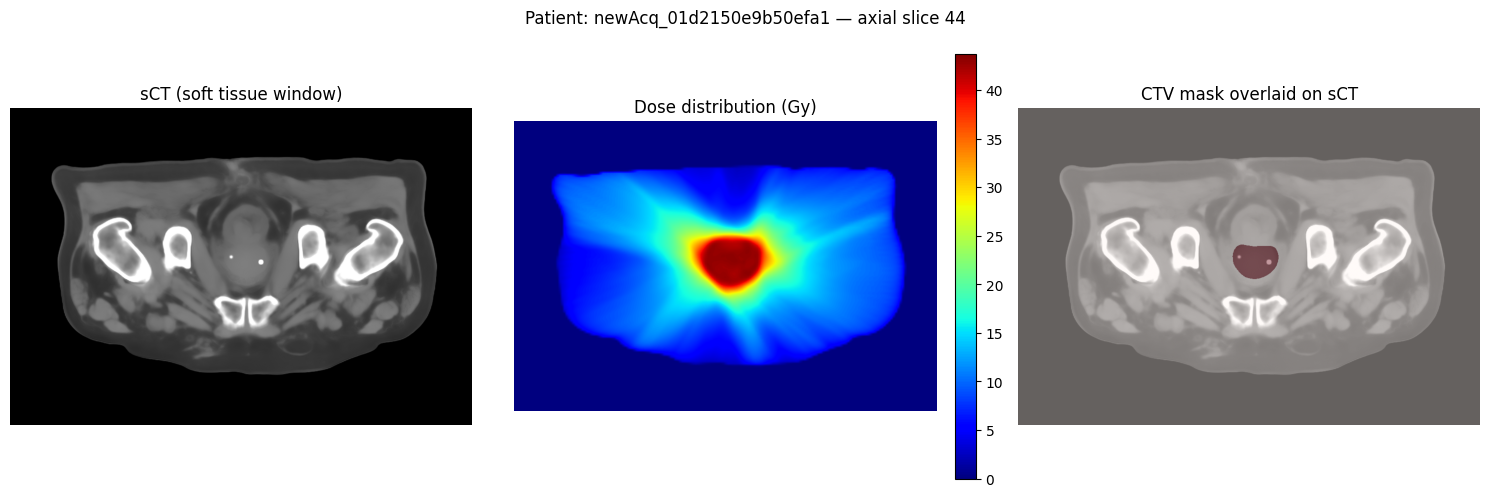

In [9]:
# Visualise the central axial slice for sCT, dose, and CTV mask.
# The central slice is often the most informative for visual inspection 
# as it typically contains the largest cross-section of the target and OARs,
# and reliably falss within the anatomy for all patients, 
# unlike the top or bottom slices which may be mostly empty air.
z_mid = sct_data.shape[2] // 2  # central slice index along Z axis

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# sCT — windowed to soft tissue range for better visual contrast.
# Full HU range (-1000 to 4000) would wash out soft tissue detail.
axes[0].imshow(sct_data[:, :, z_mid].T, cmap="gray",
               vmin=-200, vmax=300, origin="lower")
axes[0].set_title("sCT (soft tissue window)")
axes[0].axis("off")

# Dose — full range so we can see the dose gradient clearly
im = axes[1].imshow(dose_data[:, :, z_mid].T, cmap="jet",
                    vmin=0, vmax=dose_data.max(), origin="lower")
axes[1].set_title("Dose distribution (Gy)")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

# CTV mask overlaid on sCT so we can see where the target sits
axes[2].imshow(sct_data[:, :, z_mid].T, cmap="gray",
               vmin=-200, vmax=300, origin="lower")
axes[2].imshow(ctv_data[:, :, z_mid].T, cmap="Reds",
               alpha=0.4, origin="lower")
axes[2].set_title("CTV mask overlaid on sCT")
axes[2].axis("off")

fig.suptitle(f"Patient: {patient.name} — axial slice {z_mid}", fontsize=12)
plt.tight_layout()
plt.show()

### Notes and observations: single patient visuals
In the sCT you can see the pelvic anatomy: the two bright white structures on the left and right are the femoral heads (hip bones), and the central soft tissue region is the pelvis where the prostate sits. The two small bright dots near the centre are likely fiducial markers, tiny implanted seeds used to track the prostate position during treatment.

The dose distribution: a hot red core concentrated where the CTV is, surrounded by a smooth gradient that falls off toward the edges. This gradient shape, called a dose falloff is clinically intentional. The treatment aims to deliver full dose to the target while the dose to surrounding tissue drops as steeply as possible to spare OARs.

The CTV overlay confirms the red core in the dose image corresponds to the delineated target volume.

### 3.4 Dose Distribution

Dose volume is the prediction target for all three models. Here we inspect the statistical properties at the patient level and across the cohort.

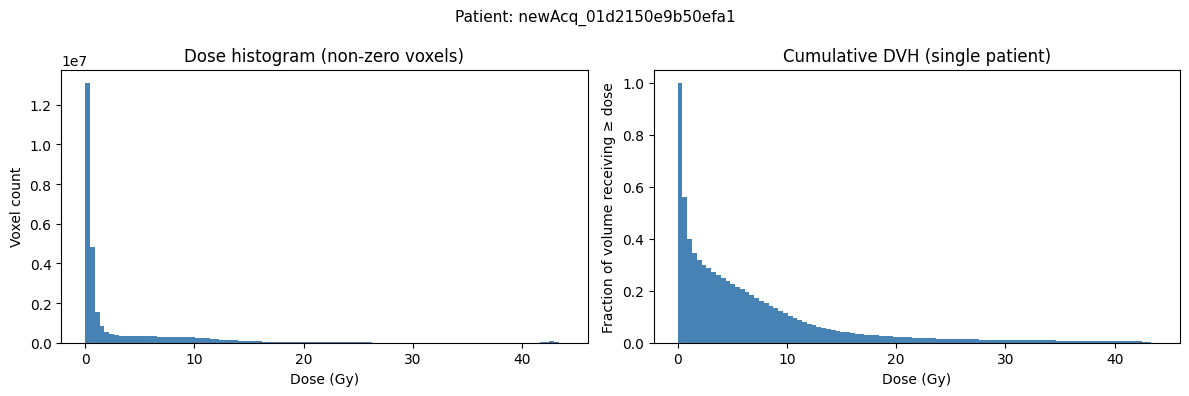

Non-zero voxel count: 29,851,349
Fraction of volume receiving full dose (>40 Gy): 0.6%


In [10]:
# Characterise the dose distribution shape for this patient.
# We look at the histogram of non-zero dose voxels — voxels receiving
# zero dose are outside the treatment field and would dominate the plot
# if included, obscuring the clinically relevant dose range.

dose_nonzero = dose_data[dose_data > 0].flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of non-zero dose voxels
axes[0].hist(dose_nonzero, bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Dose (Gy)")
axes[0].set_ylabel("Voxel count")
axes[0].set_title("Dose histogram (non-zero voxels)")

# Cumulative distribution - this is related to the DVH concept.
# A DVH (dose-volume histogram) is the standard clinical tool for
# evaluating radiotherapy plans, so understanding this shape matters
axes[1].hist(dose_nonzero, bins=100, cumulative=-1,
             density=True, color="steelblue", edgecolor="none")
axes[1].set_xlabel("Dose (Gy)")
axes[1].set_ylabel("Fraction of volume receiving ≥ dose")
axes[1].set_title("Cumulative DVH (single patient)")

fig.suptitle(f"Patient: {patient.name}", fontsize=11)
plt.tight_layout()
plt.show()

print(f"Non-zero voxel count: {len(dose_nonzero):,}")
print(f"Fraction of volume receiving full dose (>40 Gy): "
      f"{(dose_nonzero > 40).mean():.1%}")

### Observations:

Dose histogram (non-zero voxels):
- spike at left (0 Gy) indicates majoraty of non-zero voxels receive only a small dose.
    > dosevolume covers entire pelvic region but only a small portion (corresponding almost exactly to CTV) receives full dose.

Cumulative dose-volume histogram (DVH) single patient:
- primary evaluation metric for clinical radiotherapy.
- x axis = dose level, y axis = fraction of the volume receiving at least that dose.
- 0.6% of voxels receive more than 40 Gy.
    > confirms only small fraction of the volume (CTV) receive full prescribed dose.


### Notes:

Relevancy for model:
- Conceptually class imbalance, domination by low-dose voxels, rare high-dose voxels.
    > Naive training -> predicting low doses voxels very well, poor prediction on high-dose voxels (not good).
- Dose prediction accuracy most important in high-dose voxels than low-dose.
    > For training -> weighted loss function most likely needed, penalizing errors more heavily for high-dose voxels.

### Key take aways:
- Dose distribution is heavily right-skewed with most voxels receiving low dose.
- Only ~0.6% of voxels receive full therapeutic dose, reflecting the spatially concentrated nature of the treatment.
- Imbalance has a direct implication for the loss function during model training.

## 3. Dose Distribution Analysis Across Patients

The single-patient inspection revealed a heavily right-skewed dose distribution, with only ±0.6% of voxels receiving the full therapeutic dose. Here we examine whether this pattern holds across all 432 patients using the metadata CSV, and characterise the variability in maximum dose and structure volumes that will affect model training.

Max dose summary across 432 patients:
count    432.00
mean      44.25
std        0.43
min       38.32
25%       44.05
50%       44.23
75%       44.50
max       45.89
Name: doseMax (Gy) , dtype: float64

Patients with max dose below 40 Gy: 1 (0.2%)


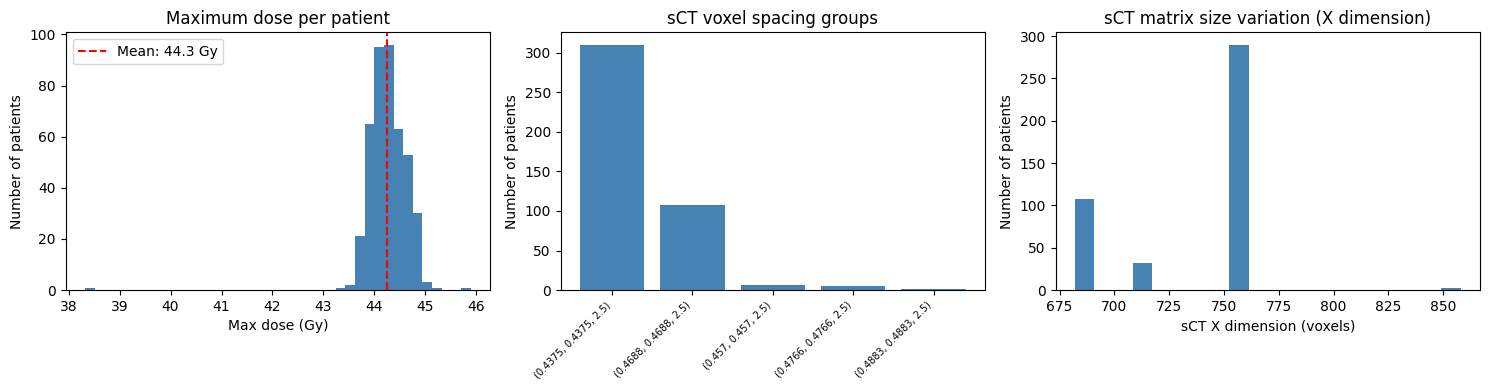

In [11]:
# Visualise the distribution of maximum dose across all 432 patients. 
# We also plot the distributions of CTV, PTV and Bladder volumes 
# to understand how much anatomical variability exists in the dataset.
# High variability in target volume size is clinically expected but
# means th emodel must generalise across a wide range of anatomy.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Maximum dose distribution
axes[0].hist(df["doseMax (Gy) "], bins=40, color="steelblue", edgecolor="none")
axes[0].axvline(df["doseMax (Gy) "].mean(), color="red",
                linestyle="--", label=f'Mean: {df["doseMax (Gy) "].mean():.1f} Gy')
axes[0].set_xlabel("Max dose (Gy)")
axes[0].set_ylabel("Number of patients")
axes[0].set_title("Maximum dose per patient")
axes[0].legend()

# We need to parse structure volume columns from the metadata CSV.
# The column names with units are stripped for cleaner code below.
dose_col   = "doseMax (Gy) "

# Pull the max dose values and describe spread
print("Max dose summary across 432 patients:")
print(df[dose_col].describe().round(2))
print(f"\nPatients with max dose below 40 Gy: "
      f"{(df[dose_col] < 40).sum()} "
      f"({(df[dose_col] < 40).mean():.1%})")

# Plot sCT voxel spacing distribution to confirm the three groups we found earlier
spacing_counts = df["sCTVoxelSizeOrig (mm)"].value_counts()
axes[1].bar(range(len(spacing_counts)), spacing_counts.values, color="steelblue")
axes[1].set_xticks(range(len(spacing_counts)))
axes[1].set_xticklabels(
    [str(s) for s in spacing_counts.index],
    rotation=45, ha="right", fontsize=7
)
axes[1].set_ylabel("Number of patients")
axes[1].set_title("sCT voxel spacing groups")

# Plot distribution of sCT X dimension to show the three size groups
x_dims = df["sCTMatrixSizeOrig"].apply(
    lambda s: int(s.strip("()").split(",")[0])
)
axes[2].hist(x_dims, bins=20, color="steelblue", edgecolor="none")
axes[2].set_xlabel("sCT X dimension (voxels)")
axes[2].set_ylabel("Number of patients")
axes[2].set_title("sCT matrix size variation (X dimension)")

plt.tight_layout()
plt.show()

### Observations:
- Maximum dose per patient:
    - Bell-shaped around 44.25 Gy with very little spread, confirming prescription protocol is standardised across all patients.
    - Two outliers around 38 Gy, they received a lower maximum dose and should be inspected before training.

- sCT voxel spacing groups:
    - One dominant spacing (310 patients at 0.4375mm).
    - Resampling to that measure is reasonable since it containts 72% of the dataset.

- Size variation of X dimension:
    - Confirming 3 clusters at around 682, 715, and 756 voxels. 
    - 756 being the dominant one. 
    - outlier near 858

Reason why to to resample and padding to a fixed grid.

In [12]:
# Verify that the heavy right-skew in dose distribution is a consistent
# property across patients, not specific to the single patient we inspected.
# We use doseMax as a proxy — if max doses are consistent, the overall
# distribution shape is likely consistent too, since the prescription
# and delivery protocol is standardised across the cohort.

low_dose_patients = (df["doseMax (Gy) "] < 40).sum()
outlier_patients  = df[df["doseMax (Gy) "] < 40]["patient"].tolist()

print(f"Patients with max dose below 40 Gy: {low_dose_patients}")
print(f"Patient IDs: {outlier_patients}")
print(f"\nThese patients will be flagged for inspection before model training.")

# Summarise the three sCT size groups for the preprocessing decision
x_dims   = df["sCTMatrixSizeOrig"].apply(
    lambda s: int(s.strip("()").split(",")[0])
)
print(f"\nsCT X dimension groups:")
print(x_dims.value_counts().sort_index())

Patients with max dose below 40 Gy: 1
Patient IDs: ['oldAcq_5691db8853d0787c']

These patients will be flagged for inspection before model training.

sCT X dimension groups:
sCTMatrixSizeOrig
682    108
716     32
756    290
858      2
Name: count, dtype: int64


> Check what to do with Omar

### 3.5 Structure Analysis

Structure masks serve as both model inputs and evaluation references. inspecting which structures are present per patient, what their volume distributions across the cohort, and the relationships between structure volumes.

### Structure Volume Analysis
Here we will look into how much the anatomy varies across patients. Specifically how large the CTV, PTV, and the OAR are (bladder and rectum), and how much that varies. This matters because a model that only sees small prostates during training will struggle with large ones at test time, and understanding the range and structure sizes tells you whether the dataset covers the anatomical spectrum properly.

In [13]:
# Print all column names 
for col in df.columns:
    print(col)

patient
sCTMatrixSizeOrig
sCTVoxelSizeOrig (mm)
mriMatrixSize
mriVoxelSize (mm)
doseMatrixSizeOrig
doseVoxelSizeOrig
doseMin (Gy)
doseMax (Gy) 


In [14]:
# Compute CTV and Bladder volumes for all 432 patients by loading their
# structure masks directly. We focus on CTV (treatment target) and Bladder
# (the most variable OAR) as representative structures.
# Volume = number of foreground voxels × voxel volume in cc.

from tqdm import tqdm

records = []

for patient in tqdm(patient_dirs, desc="Loading structure volumes"):
    sct_dir = patient / "sCT"
    
    # Read voxel spacing from the sCT header — needed to compute physical volume
    sct_img = nib.load(sct_dir / "image.nii.gz")
    voxel_vol_cc = np.prod(sct_img.header.get_zooms()) / 1000
    
    row = {"patient": patient.name}
    
    # Load each structure mask and compute its volume
    for structure, filename in [
        ("CTV",     "mask_CTVT_427.nii.gz"),
        ("PTV",     "mask_PTVT_427.nii.gz"),
        ("Bladder", "mask_Bladder.nii.gz"),
        ("Rectum",  "mask_Rectum.nii.gz"),
    ]:
        mask_path = sct_dir / filename
        if mask_path.exists():
            mask = nib.load(mask_path).get_fdata()
            row[f"{structure}_cc"] = mask.sum() * voxel_vol_cc
        else:
            # Record NaN for missing structures rather than crashing
            row[f"{structure}_cc"] = np.nan
    
    records.append(row)

volumes_df = pd.DataFrame(records)
print(f"\nVolume dataframe shape: {volumes_df.shape}")
print(volumes_df.describe().round(1))

Loading structure volumes: 100%|██████████| 432/432 [17:16<00:00,  2.40s/it]


Volume dataframe shape: (432, 5)
       CTV_cc  PTV_cc  Bladder_cc  Rectum_cc
count   432.0   432.0       432.0      432.0
mean     56.4   133.3       160.7       66.3
std      22.3    38.9        97.9       23.8
min      19.3    60.3        33.8       24.1
25%      41.3   105.8        90.4       50.7
50%      52.0   125.8       135.3       61.5
75%      66.9   153.5       203.2       75.5
max     164.6   313.8       573.3      197.5


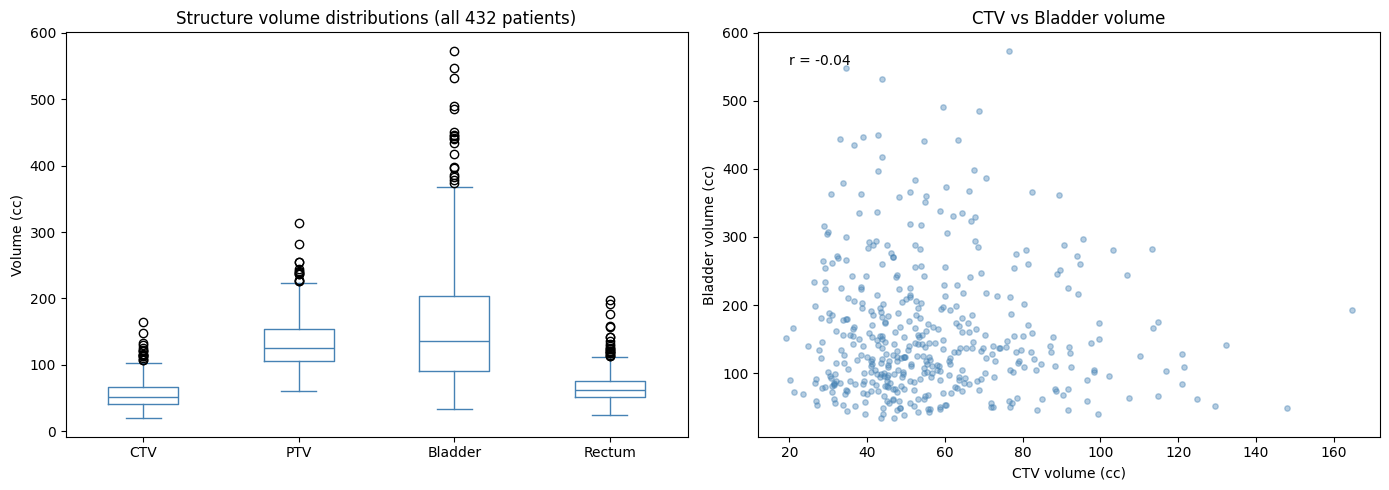

In [17]:
# Visualise structure volume distributions across all patients.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plots for the four structures.
volumes_df[["CTV_cc", "PTV_cc", "Bladder_cc", "Rectum_cc"]].plot.box(
    ax=axes[0], color="steelblue"
)
axes[0].set_ylabel("Volume (cc)")
axes[0].set_title("Structure volume distributions (all 432 patients)")
axes[0].set_xticklabels(["CTV", "PTV", "Bladder", "Rectum"])

# Scatter plot of CTV vs Bladder volume, which are the most variable structures.
# If these correlate, it might indicate a clinical pattern where larger tumors are associated with larger bladders,
# which could affect model learning.
axes[1].scatter(volumes_df["CTV_cc"], volumes_df["Bladder_cc"],
                alpha=0.4, color="steelblue", s=15)
axes[1].set_xlabel("CTV volume (cc)")
axes[1].set_ylabel("Bladder volume (cc)")
axes[1].set_title("CTV vs Bladder volume")

# Add correlation coefficient as a reference.
corr = volumes_df["CTV_cc"].corr(volumes_df["Bladder_cc"])
axes[1].text(0.05, 0.92, f"r = {corr:.2f}",
             transform=axes[1].transAxes, fontsize=10)

plt.tight_layout()
plt.show()

## EDA Findings

Data description.
all 432 patients are present with complete file structures. The sCT varies across patients, three dominant in-plane spacing groups (0.4375, 0.4688, 0.457mm) and X dimesnions clustering around 682, 716 an 756 voxels, while MR geometry is uniform at 1024x1024x88. Missing structures affect only 48 patients, limited to PenileBulb and Genetalia, with CTV and PTV complete for all patients. The dose distribution is heavily right-skewed with only around 0.6% of voxels receiving full therapeutic dose, and maximum dose is tightly standardised around 44.3 Gy across patients. One patient received a notably lower max dose and warrants inspection. Structure volumes show cllinically exepcted variability, with bladder being the most variable organ and CTV and bladder volumes being uncorrelated, ruling out systematic acqisition confounds.